# Assignment 1  

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [83]:
# 1. Create a stable time series following AR(1)

np.random.seed(42)

T = 300
coef = [0.7]
mat = []

for i in range(len(coef)):
    a = np.eye(T) + np.eye(T,k=-1)*-coef[i]
    mat.append(a)

# stochastic
y2 = []
e2 = np.random.normal(0,0.001, size=(T,1))

for i in range(len(coef)):
    a = np.linalg.inv(mat[i])@e2
    y2.append(a)

y2

[array([[ 4.96714153e-04],
        [ 2.09435606e-04],
        [ 7.94293462e-04],
        [ 2.07903528e-03],
        [ 1.22117132e-03],
        [ 6.20682968e-04],
        [ 2.01369089e-03],
        [ 2.17701835e-03],
        [ 1.05443846e-03],
        [ 1.28066697e-03],
        [ 4.33049184e-04],
        [-1.62595325e-04],
        [ 1.28145544e-04],
        [-1.82357836e-03],
        [-3.00142269e-03],
        [-2.66328341e-03],
        [-2.87712951e-03],
        [-1.69974332e-03],
        [-2.09784440e-03],
        [-2.88079478e-03],
        [-5.50907579e-04],
        [-6.11411606e-04],
        [-3.60459919e-04],
        [-1.67707013e-03],
        [-1.71833182e-03],
        [-1.09190968e-03],
        [-1.91533035e-03],
        [-9.65033230e-04],
        [-1.27616195e-03],
        [-1.18500712e-03],
        [-1.43121159e-03],
        [ 8.50430069e-04],
        [ 5.81803824e-04],
        [-6.50448252e-04],
        [ 3.67231136e-04],
        [-9.63781855e-04],
        [-4.65783704e-04],
 

Coefficient: 0.7
Stable: True


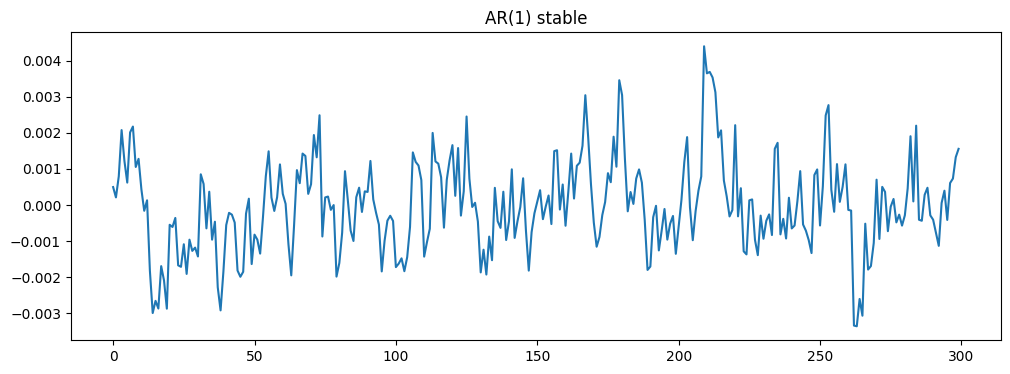

In [85]:
# 2. Check the stability and vizualize

print('Coefficient:', coef[0])
print('Stable:', abs(coef[0]) < 1)

plt.figure(figsize=(12, 4))
plt.plot(y2[0])
plt.title('AR(1) stable')
plt.show()

In [ ]:
# 3. Estimate AR(1) and discuss the results

import statsmodels.api as sm

y = y2[0].flatten()

Y = y[1:]
X = y[:-1]

model = sm.OLS(Y, X)
results = model.fit()

print(results.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.418
Model:                            OLS   Adj. R-squared (uncentered):              0.416
Method:                 Least Squares   F-statistic:                              214.1
Date:                Fri, 18 Sep 2026   Prob (F-statistic):                    6.59e-37
Time:                        22:18:11   Log-Likelihood:                          1646.7
No. Observations:                 299   AIC:                                     -3291.
Df Residuals:                     298   BIC:                                     -3288.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [ ]:
print('True coefficient:', coef[0])
print('Estimated coefficient:', results.params[0])

True coefficient: 0.7
Estimated coefficient: 0.648001768730673


The true coefficient which was used to generate data = 0.7, whule estimated coefficient by OLS estimate = 0.65. The estimate is close to real value.  The estimated coefficient is statistically significant(p=0.000). R squared is 0.418, meaning that the lagged value of the series explains approximately 42% of the variation in the dependent variable

In [ ]:
# 4. Create a unstable fluctuating time series in line with AR(2)

np.random.seed(42)
T = 300
A = [[1.6, -1.1]]

y2_ar2 = []
e2 = np.random.normal(0, 0.001, size=(T, 1))

for i in range(len(A)):
    mat = (np.eye(T)+np.eye(T, k=-1) * -A[i][0] + np.eye(T, k=-2) * -A[i][1])

    a = np.linalg.inv(mat) @ e2
    y2_ar2.append(a)

y2_ar2

[array([[ 4.96714153e-04],
        [ 6.56478344e-04],
        [ 1.15166832e-03],
        [ 2.64357299e-03],
        [ 2.72872826e-03],
        [ 1.22389797e-03],
        [ 5.35848478e-04],
        [ 2.78504531e-04],
        [-6.13300462e-04],
        [-7.45075679e-04],
        [-9.80908272e-04],
        [-1.21559974e-03],
        [-6.23998216e-04],
        [-1.57451767e-03],
        [-3.55774807e-03],
        [-4.52271501e-03],
        [-4.33565225e-03],
        [-1.64780976e-03],
        [ 1.22469778e-03],
        [ 2.35980349e-03],
        [ 3.89416679e-03],
        [ 3.40910672e-03],
        [ 1.23851549e-03],
        [-3.19314079e-03],
        [-7.01577503e-03],
        [-7.60186259e-03],
        [-5.59662119e-03],
        [-2.16847035e-04],
        [ 5.20868936e-03],
        [ 8.28074097e-03],
        [ 6.91792064e-03],
        [ 3.81213614e-03],
        [-1.52379210e-03],
        [-7.68912805e-03],
        [-9.80388865e-03],
        [-8.44902464e-03],
        [-2.52529831e-03],
 

Coefficients: 1.6 -1.1
Discriminant: -1.8399999999999999
Stable: False


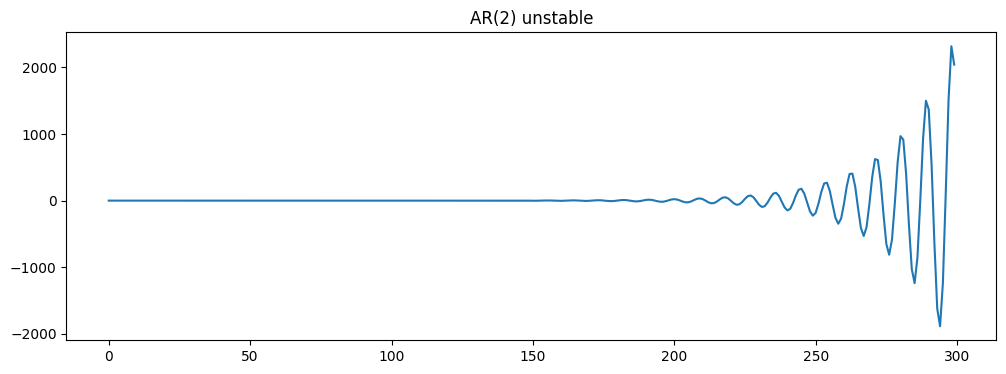

In [ ]:
# 5. Check the stability and vizualize

a1 = A[0][0]
a2 = A[0][1]

d = a1**2 + 4*a2

print('Coefficients:', a1, a2)
print('Discriminant:', d)
print('Stable:', abs(a2) < 1)

plt.figure(figsize=(12, 4))
plt.plot(y2_ar2[0])
plt.title('AR(2) unstable')
plt.show()

In [ ]:
# 6. Estimate AR(2) and discuss the results

y = y2_ar2[0].flatten()

Y = y[2:]
X = np.column_stack((y[1:-1], y[:-2]))

model = sm.OLS(Y, X)
results = model.fit()

print(results.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   1.000
Model:                            OLS   Adj. R-squared (uncentered):              1.000
Method:                 Least Squares   F-statistic:                          1.802e+13
Date:                Fri, 18 Sep 2026   Prob (F-statistic):                        0.00
Time:                        22:31:29   Log-Likelihood:                          1640.1
No. Observations:                 298   AIC:                                     -3276.
Df Residuals:                     296   BIC:                                     -3269.
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [ ]:
# coefficients comparison

print("True a1:", 1.6)
print("Estimated a1:", results.params[0])

print("True a2:", -1.1)
print("Estimated a2:", results.params[1])


# estimated roots

estimated_roots = np.roots([1,-results.params[0],-results.params[1]])
print("Estimated roots:", estimated_roots)

True a1: 1.6
Estimated a1: 1.6000001126880743
True a2: -1.1
Estimated a2: -1.1000001157921069
Estimated roots: [0.80000006+0.67823302j 0.80000006-0.67823302j]


The true coefficients a1=1.6 and a2=-1.1, while the estimated coefficients are 1.600 and -1.100.  

OLS estimates are almost identical to the true values. Both coefficients are statistically significant(p < 0.001)

R squared = 1.000, so almost perfect fit between the lagged variables and the dependent variable. The estimated coefficients also confirm the unstable AR(2), because |a2| = 1.1 > 1

# Assignment 2

In [ ]:
# 1. Create a stable time series in line with VAR(1)

np.random.seed(42)

T = 300
A = np.array([
    [0.5, 0.2],
    [0.1, 0.4]
])

e = np.random.normal(0, 0.001, size=(T, 2))
Y = np.zeros((T, 2))

for t in range(1, T):
    Y[t] = A @ Y[t-1] + e[t]

Y


array([[ 0.00000000e+00,  0.00000000e+00],
       [ 6.47688538e-04,  1.52302986e-03],
       [ 3.94296866e-04,  4.39843839e-04],
       [ 1.86433002e-03,  9.82801951e-04],
       [ 6.59251012e-04,  1.12211383e-03],
       [ 9.06305786e-05,  4.90408780e-05],
       [ 2.97085736e-04, -1.88460084e-03],
       [-1.95329513e-03, -1.28641929e-03],
       [-2.24676254e-03, -3.95649896e-04],
       [-2.11053533e-03, -1.79523991e-03],
       [ 5.13331226e-05, -1.15492580e-03],
       [-1.37790394e-04, -1.88158519e-03],
       [-9.89594960e-04, -6.55490527e-04],
       [-1.77688916e-03,  1.45423115e-05],
       [-1.48617481e-03, -4.63565741e-04],
       [-1.43750717e-03,  1.51823441e-03],
       [-4.28603926e-04, -5.94167883e-04],
       [ 4.89409373e-04, -1.50137120e-03],
       [ 1.53294042e-04, -2.51127766e-03],
       [-1.75379456e-03, -7.92320426e-04],
       [-2.96894786e-04, -3.20939345e-04],
       [-3.28283544e-04, -4.59168912e-04],
       [-1.73449754e-03, -9.36340128e-04],
       [-1.

In [ ]:
# 2. Estimate VAR model and report the results


from statsmodels.tsa.api import VAR

model = VAR(Y)
results = model.fit(1)

print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 18, Sep, 2026
Time:                     22:46:15
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -27.6349
Nobs:                     299.000    HQIC:                  -27.6794
Log likelihood:           3299.99    FPE:                9.24840e-13
AIC:                     -27.7092    Det(Omega_mle):     9.06557e-13
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const        -0.000015         0.000057           -0.259           0.796
L1.y1         0.462609         0.050631            9.137           0.000
L1.y2         0.170374         0.054383            3.133           0.002

Results for equation 

The estimated coefficients are close to true coefficients.  

1st equation: the coefficient of the first lag of y1=0.46, compared with the true value of 0.5, while the coefficient of the first lag of y2=0.17, compared with the true value of 0.2.   

2nd equation: the estimated coefficients for the first lag of y1=0.15 and  for the first lag of y2=0.36, compared with the true values of 0.1 and 0.4.

All four lagged variables are statistically significant(p < 0.05)  

Lagged values of both variables contribute significantly to their respective equations. The estimated VAR(1) model recovers the general relationship between the two time series used to generate the data.

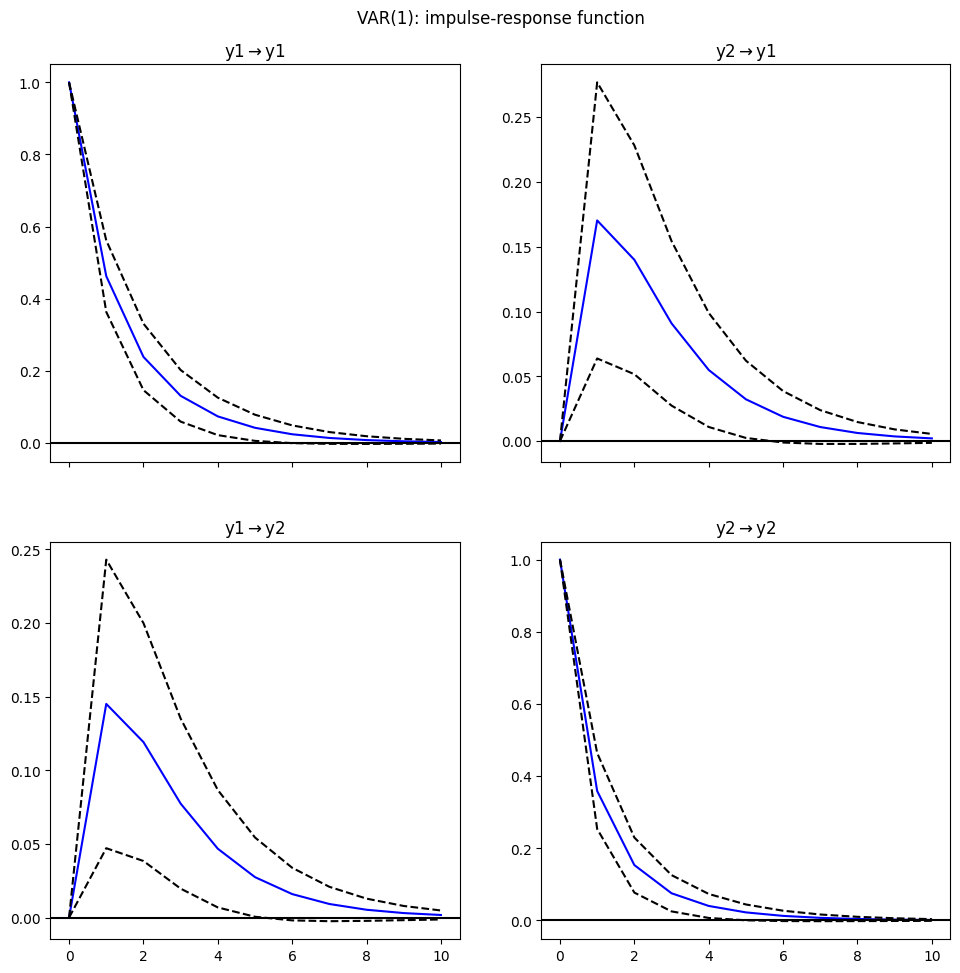

[[[1.         0.        ]
  [0.         1.        ]]

 [[0.46260861 0.17037353]
  [0.14508854 0.35889385]]

 [[0.23872597 0.13996227]
  [0.11919059 0.15352404]]

 [[0.13074361 0.09090419]
  [0.07741317 0.07540576]]

 [[0.07367228 0.0549002 ]
  [0.04675251 0.04025182]]

 [[0.04204682 0.03225515]
  [0.02746819 0.02241152]]

 [[0.02413107 0.01873984]
  [0.01595868 0.01272321]]

 [[0.01388218 0.01083691]
  [0.00922861 0.00728522]]

 [[0.00799433 0.00625446]
  [0.00532624 0.00418693]]

 [[0.00460569 0.00360671]
  [0.00307144 0.00241011]]

 [[0.00265393 0.00207911]
  [0.00177055 0.00138827]]]


In [ ]:
# 3. Visualize impulse-response plot

irf = results.irf(10)

irf.plot()
plt.suptitle('VAR(1): impulse-response function')
plt.show()

print(irf.irfs)

<Figure size 640x480 with 0 Axes>

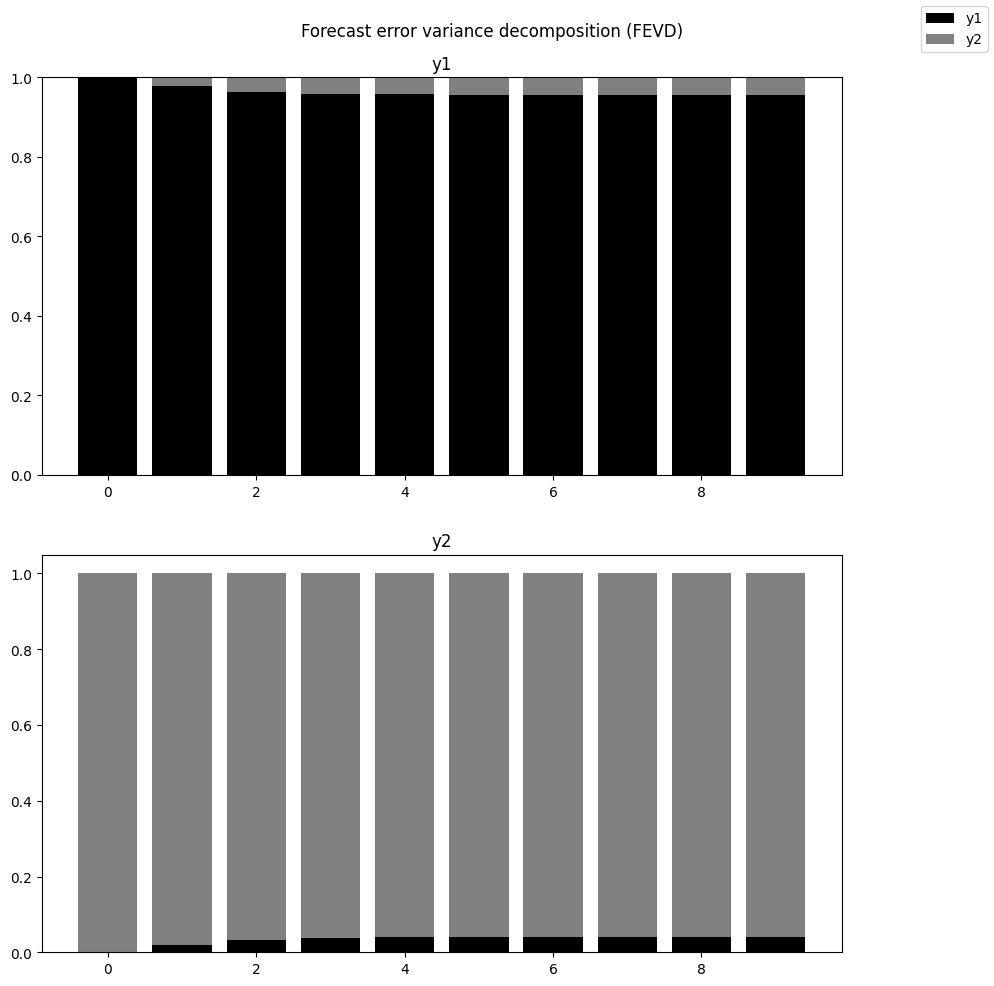

FEVD for y1
           y1        y2
0    1.000000  0.000000
1    0.977274  0.022726
2    0.964155  0.035845
3    0.958856  0.041144
4    0.956947  0.043053
5    0.956290  0.043710
6    0.956069  0.043931
7    0.955995  0.044005
8    0.955970  0.044030
9    0.955962  0.044038

FEVD for y2
           y1        y2
0    0.000215  0.999785
1    0.020305  0.979695
2    0.032349  0.967651
3    0.037284  0.962716
4    0.039068  0.960932
5    0.039682  0.960318
6    0.039889  0.960111
7    0.039959  0.960041
8    0.039982  0.960018
9    0.039989  0.960011


None


In [ ]:
# 4. Forecast error variance decomposition


fevd = results.fevd(10)
plt.suptitle(
    "Forecast error variance decomposition for VAR(1)"
)
fevd.plot()
plt.show()

print(fevd.summary())


In [ ]:
# 5. Repeat steps 1-4 adding an intercept column

# 5.1 Create a stable VAR(1) with an intercept

np.random.seed(42)

T = 300
A = np.array([
    [0.5, 0.2],
    [0.1, 0.4]
])

c = np.array([0.001, 0.001])
e = np.random.normal(0, 0.001, size=(T, 2))
Y = np.zeros((T, 2))

for t in range(1, T):
    Y[t] = c + A @ Y[t-1] + e[t]

Y

array([[ 0.00000000e+00,  0.00000000e+00],
       [ 1.64768854e-03,  2.52302986e-03],
       [ 2.09429687e-03,  1.93984384e-03],
       [ 4.01433002e-03,  2.75280195e-03],
       [ 3.08825101e-03,  3.04511383e-03],
       [ 2.68973058e-03,  2.06114088e-03],
       [ 2.99905574e-03,  1.80149164e-04],
       [ 8.10639869e-04,  8.09677710e-04],
       [ 5.54424356e-04,  1.71918240e-03],
       [ 7.13024583e-04,  3.30811696e-04],
       [ 2.88832340e-03,  9.77850836e-04],
       [ 2.70726007e-03,  2.55224488e-04],
       [ 1.86029221e-03,  1.48373839e-03],
       [ 1.07590021e-03,  2.15522260e-03],
       [ 1.36835593e-03,  1.67798531e-03],
       [ 1.41806842e-03,  3.66030790e-03],
       [ 2.42759856e-03,  1.54821907e-03],
       [ 3.34598801e-03,  6.41203836e-04],
       [ 3.01009837e-03, -3.68589789e-04],
       [ 1.10314518e-03,  1.35043516e-03],
       [ 2.56012620e-03,  1.82185686e-03],
       [ 2.52878619e-03,  1.68365167e-03],
       [ 1.12260144e-03,  1.20649508e-03],
       [ 1.

In [ ]:
# 5.2 Estimate VAR(1) with an intercept

from statsmodels.tsa.api import VAR

model = VAR(Y)

results = model.fit(1, trend='c')

print(results.summary())



  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 18, Sep, 2026
Time:                     22:59:43
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -27.6357
Nobs:                     299.000    HQIC:                  -27.6802
Log likelihood:           3300.11    FPE:                9.24118e-13
AIC:                     -27.7099    Det(Omega_mle):     9.05849e-13
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         0.001175         0.000174            6.773           0.000
L1.y1         0.457861         0.050208            9.119           0.000
L1.y2         0.166570         0.054311            3.067           0.002

Results for equation 

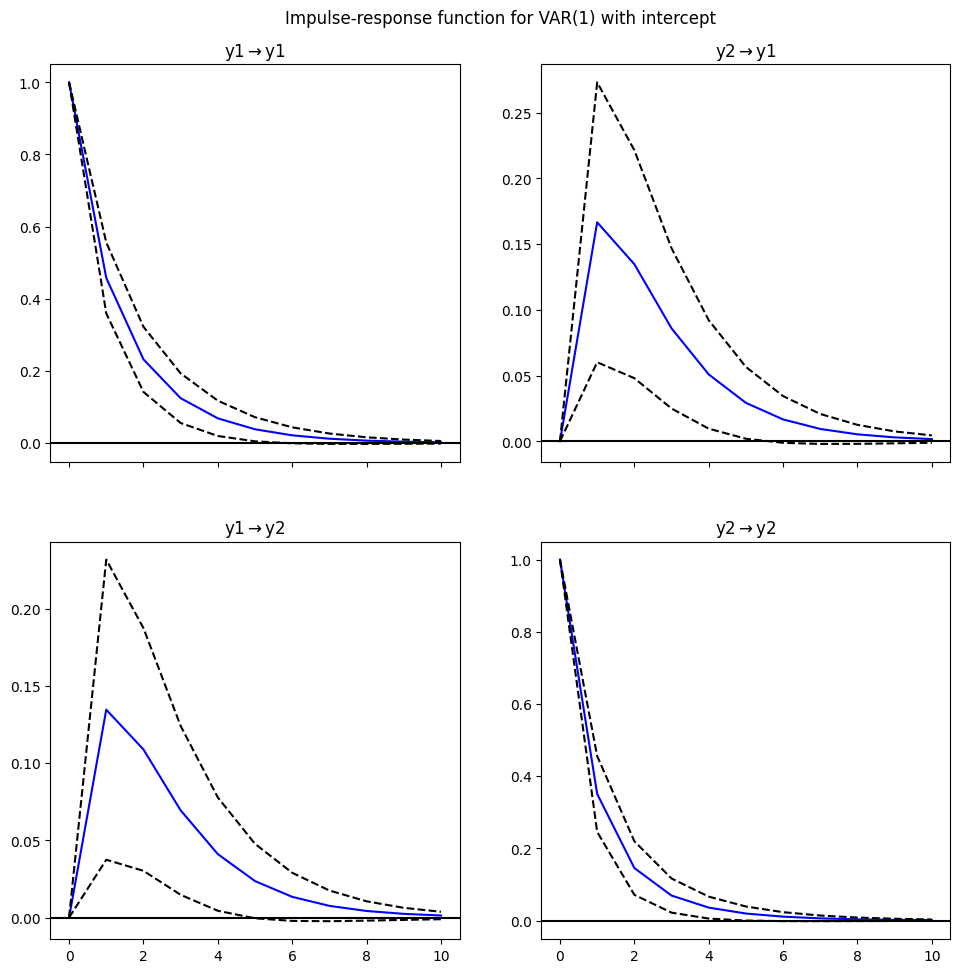

[[[1.         0.        ]
  [0.         1.        ]]

 [[0.45786096 0.16656976]
  [0.13470207 0.35079869]]

 [[0.23207395 0.13469825]
  [0.10892813 0.14549701]]

 [[0.12440174 0.08590847]
  [0.06947269 0.06918429]]

 [[0.06853075 0.05085815]
  [0.0411281  0.03584181]]

 [[0.03822825 0.02925612]
  [0.02365892 0.01942396]]

 [[0.02144408 0.01663068]
  [0.01344894 0.01075476]]

 [[0.0120586  0.00940596]
  [0.00760643 0.00601294]]

 [[0.00678816 0.00530819]
  [0.00429264 0.00337633]]

 [[0.00382306 0.00299281]
  [0.00242023 0.00189944]]

 [[0.00215357 0.00168668]
  [0.00136399 0.00106946]]]


In [ ]:
# 5.3 Visualize impulse-response plot

irf = results.irf(10)

irf.plot()
plt.suptitle('Impulse-response function for VAR(1) with intercept')
plt.show()

print(irf.irfs)

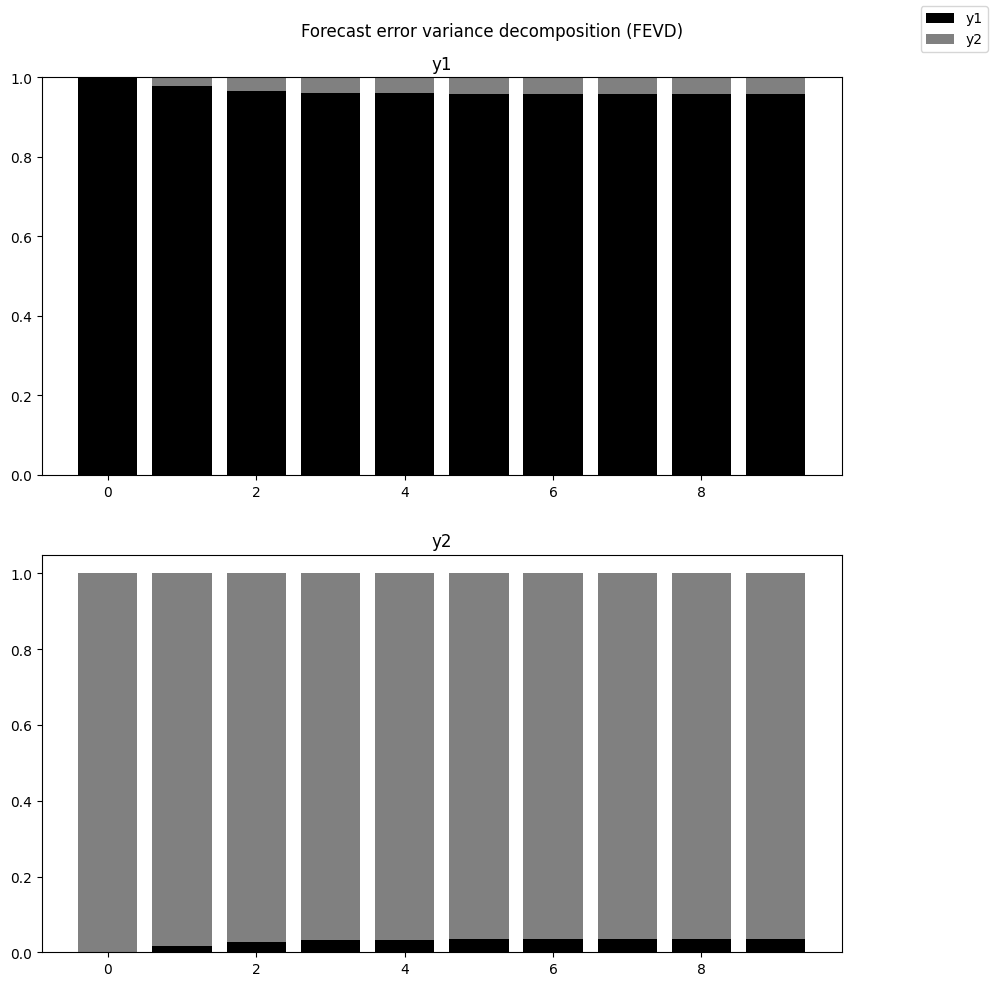

FEVD for y1
           y1        y2
0    1.000000  0.000000
1    0.978148  0.021852
2    0.965855  0.034145
3    0.961045  0.038955
4    0.959377  0.040623
5    0.958826  0.041174
6    0.958647  0.041353
7    0.958591  0.041409
8    0.958572  0.041428
9    0.958567  0.041433

FEVD for y2
           y1        y2
0    0.000188  0.999812
1    0.017603  0.982397
2    0.027808  0.972192
3    0.031859  0.968141
4    0.033268  0.966732
5    0.033734  0.966266
6    0.033885  0.966115
7    0.033933  0.966067
8    0.033948  0.966052
9    0.033953  0.966047


None


In [ ]:
# 5.4 Forecast Error Variance Decomposition

fevd = results.fevd(10)

fevd.plot()
plt.show()
print(fevd.summary())